In [1]:
# This is an example obtained from the odl repository. Not my code

"""Example using the ray transform with helical cone beam geometry."""

import numpy as np
import odl

In [11]:
# Reconstruction space: discretized functions on the cube
# [-20, 20]^2 x [0, 40] with 300 samples per dimension.
reco_space = odl.uniform_discr(
    min_pt=[-20, -20, 0], max_pt=[20, 20, 40], shape=[300, 300, 300],
    dtype='float32')
reco_space.size

27000000

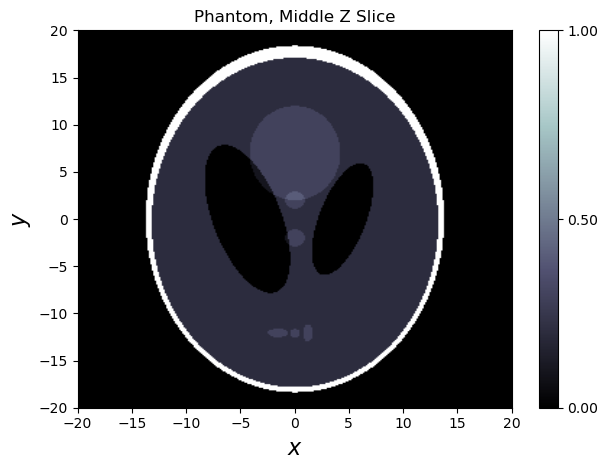

<Figure size 640x480 with 0 Axes>

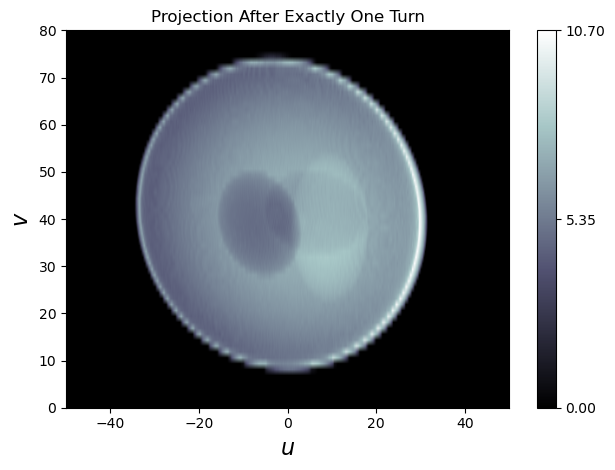

<Figure size 640x480 with 0 Axes>

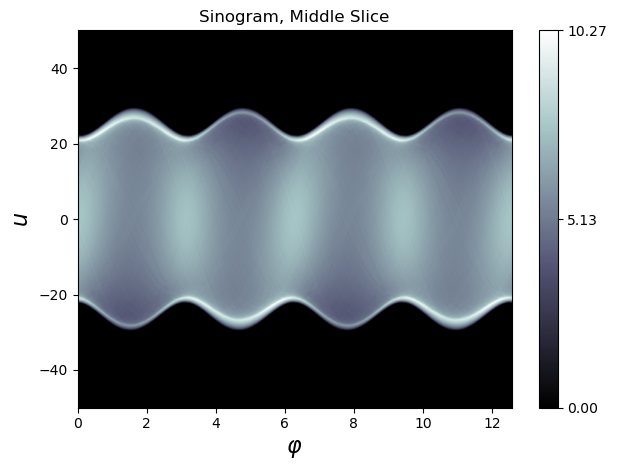

<Figure size 640x480 with 0 Axes>

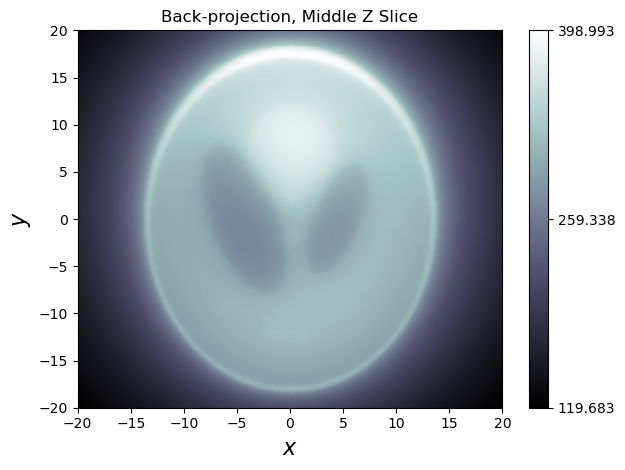

<Figure size 640x480 with 0 Axes>

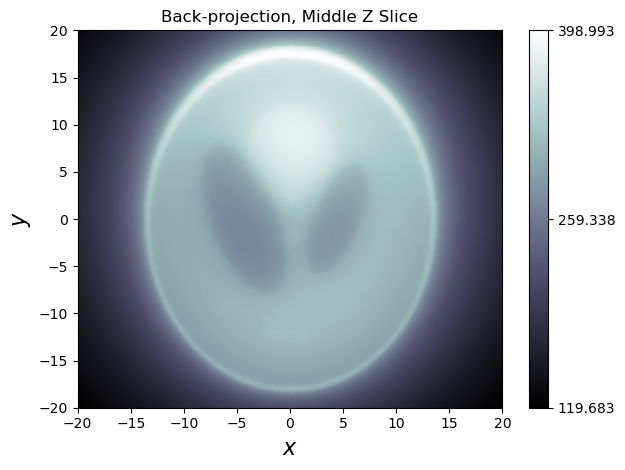

In [46]:

# Make a helical cone beam geometry with flat detector
# Angles: uniformly spaced, n = 2000, min = 0, max = 8 * 2 * pi
angle_partition = odl.uniform_partition(0, 2 * 2 * np.pi, 2000)
# Detector: uniformly sampled, n = (512, 64), min = (-50, -3), max = (50, 3)
detector_partition = odl.uniform_partition([-50, 0], [50, 80], [512, 64])
# Spiral has a pitch of 5, we run 8 rounds (due to max angle = 8 * 2 * pi)
geometry = odl.tomo.ConeBeamGeometry(
    angle_partition, detector_partition, src_radius=100, det_radius=100,
    pitch=0)

# Ray transform (= forward projection).
ray_trafo = odl.tomo.RayTransform(reco_space, geometry)

# Create a discrete Shepp-Logan phantom (modified version)
phantom = odl.phantom.shepp_logan(reco_space, modified=True)

# Create projection data by calling the ray transform on the phantom
proj_data = ray_trafo(phantom)

# Back-projection can be done by simply calling the adjoint operator on the
# projection data (or any element in the projection space).
backproj = ray_trafo.adjoint(proj_data)

# Shows a slice of the phantom, projections, and reconstruction
phantom.show(coords=[None, None, 20], title='Phantom, Middle Z Slice')
proj_data.show(coords=[(1/4) * np.pi, None, None],
               title='Projection After Exactly One Turn')
proj_data.show(coords=[None, None, 20], title='Sinogram, Middle Slice')
backproj.show(coords=[None, None, 20], title='Back-projection, Middle Z Slice',
              force_show=True)

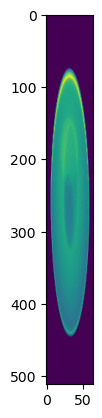

In [49]:
import matplotlib.pyplot as plt
plt.imshow(proj_data[800])
# proj_data

In [ ]:
for i in range(8):
    